## Step 1: Parameters Preparation

In [1]:
# Manual paramters

width_sub='optm' # 'orig' from river product, 'optm' from raster product , 'shft' process inter-track calibration based on optm.  
type_sub='obs' # 'obs' or 'fit'. Use observed or fitted width to estimate


total_neighbor_reach=[73254400131, 73254400121, 73254400111, 73254400101] # choose continuous reaches from upstream to downstream
total_neighbor_prior_dem=[70,62.5,59.5,56] # DEM reference
total_neighbor_length=[11761.601934, 17991.484189, 18008.947238, 18808.762305] # legth from SWORD
choose_index=list(range(len(total_neighbor_reach))) # Select some of the reaches

target_reachid=73254400101 # target reachid to be validated
S3_nodeid='73254400110231' # optional, if not provided, set to None
median_bias=4 # optional, if not provided, set to None

print('type_sub:',type_sub,', width_sub:',width_sub)

type_sub: obs , width_sub: optm


In [2]:
import os
import sys
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely import Point, Polygon, box
import netCDF4 as nc
import requests
from io import StringIO
import matplotlib.dates as mdates
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from math import ceil, sqrt
from scipy.stats import pearsonr,spearmanr
from shapely import wkt
import rasterio
from rasterio import features
from rasterio.warp import calculate_default_transform, reproject, Resampling  # Note this change
from matplotlib.colors import ListedColormap
from shapely.geometry import LineString
import pwlf
import rasterio.mask

In [3]:
# Plot settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
# Get prior info like reachid, u can run this cell first to get the neighbor info

# jupyter_path=os.path.dirname(os.path.abspath("__file__"))
# src_path=os.path.join(os.path.dirname(jupyter_path),'src')
# sys.path.append(src_path)
# from preparation import get_neighbor_info
# a,b,c=get_neighbor_info(73254400101,2,2)
# print('\nneighbor reach id:',a)
# print('neighbor reach dem:',b)
# print('neighbor reach length:',c)


In [5]:
# # get dem from hydrocon, alternatively

# hydrocon_dem_list=[]
# for id in range(len(total_neighbor_reach)):
#     hydrocron_response = requests.get(
#         f"https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries?feature=Reach&feature_id={total_neighbor_reach[id]}"
#         f"&start_time=2023-01-01T00:00:00Z&end_time=2025-03-20T00:00:00Z&output=csv&fields=reach_id,time_str,wse,width,slope2,reach_q,reach_q_b,geometry"
#     ).json()
#     if 'results' in hydrocron_response and 'csv' in hydrocron_response['results']:
#         csv_str=hydrocron_response['results']['csv']
#         df_reach = pd.read_csv(StringIO(csv_str))
#         val=round(np.nanmedian(df_reach['wse'][df_reach['wse']>-100]),1)
#         print(f"{id}: {val} m")
#         hydrocon_dem_list.append(float(val))
# print("hydrocon_dem_list:",hydrocon_dem_list)
# # df_reach

In [ ]:
# Jupyter parameters

jupyter_path=os.path.dirname(os.path.abspath("__file__"))
src_path=os.path.join(os.path.dirname(jupyter_path),'src')
sys.path.append(src_path)

raster_path_base=r"path\to\your\width\excel" # Necessary if width_sub is 'optm' or 'shft'

prior_path=r"path\to\your\SoS\na_sword_v16_SOS_unconstrained_0001_20240611T010141_priors.nc"
S3_json_path=r"path\to\your\S3json" # Necessary if run reconstruction part
result_path=prior_path.replace('priors','results')
# Ajust paths based on the current notebook location

neighbor_reach=[total_neighbor_reach[i] for i in choose_index]
neighbor_prior_dem=[total_neighbor_prior_dem[i] for i in choose_index]
neighbor_length=[total_neighbor_length[i] for i in choose_index]
t_idx_org=int(np.where(np.array(total_neighbor_reach)==target_reachid)[0][0])
target_reach_index=int(np.where(np.array(neighbor_reach)==target_reachid)[0][0])

print("target reach index:",target_reach_index)

target reach index: 3


## Step 2: Obtain SWOT Observations

In [7]:
# Obtain high-quality observations
from preparation import hydrocon_preparation
df_reaches,prior_slope=hydrocon_preparation(width_sub,total_neighbor_reach,total_neighbor_prior_dem,total_neighbor_length,\
        choose_index,target_reachid,raster_path_base,prior_slope=-1)
number_reaches=len(df_reaches)

prior_slope: -1
pre 0 73254400131
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400131.xlsx
reach 73254400131 width optimized
pre 1 73254400121
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400121.xlsx
reach 73254400121 width optimized
pre 2 73254400111
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400111.xlsx
reach 73254400111 width optimized
pre 3 73254400101
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400101.xlsx
reach 73254400101 width optimized
pre_common_dates: 19
data start from: 2023-12-29 00:00:00
proc 0 73254400131
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400131.xlsx
reach 73254400131 width optimized
proc 1 73254400121
D:\WorkStation\SWOT\discharge\raster_width\center_73254400101\width_raw_73254400121.xlsx
reach 73254400121 width optimized
proc 2 73254400111
D:\WorkStation\SWOT\discharge\raster_width\center_732544001

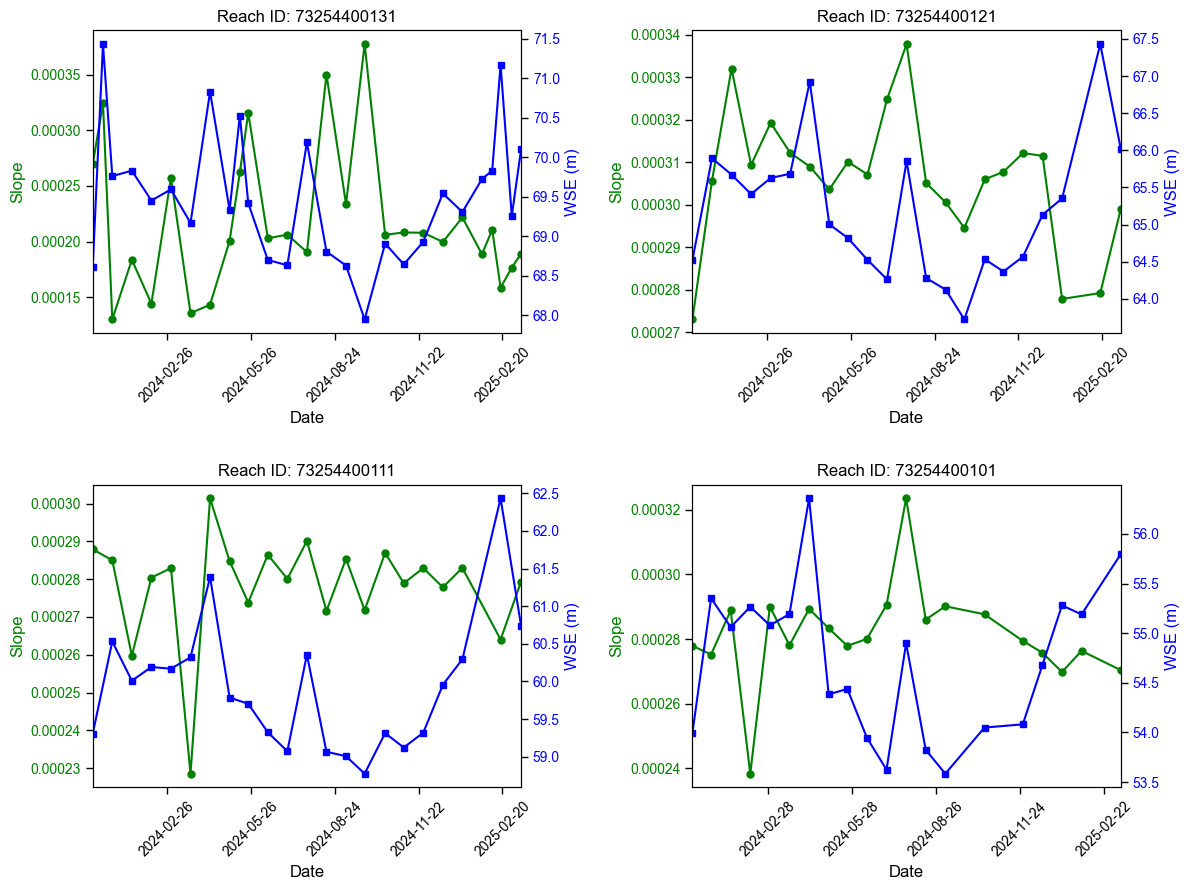

In [8]:
# Plot slope & WSE series
def show_all_reaches_slope_series(df_reaches):
    number_figs=len(df_reaches)
    nrows=int(sqrt(number_figs))
    ncols=ceil(number_figs/nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 9), squeeze=False)
    
    axes_flat = axes.flatten()
    
    for i, df_reach in enumerate(df_reaches):
        if i < number_figs:
            ax = axes_flat[i]
            
            ax.plot(df_reach.date, df_reach.slope2, '-', color='green', marker='o', markersize=5)
            ax.set_xlabel('Date', fontdict={'size':12})
            ax.set_ylabel('Slope', fontdict={'size':12}, color='green')
            ax.tick_params(axis='y', labelcolor='green', labelsize=10)
            ax.tick_params(which='major', length=5, width=1)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            ax.tick_params(axis='x', labelrotation=45, labelsize=10)
            
            ax2 = ax.twinx()
            ax2.plot(df_reach.date, df_reach.wse, '-', color='blue', marker='s', markersize=5)
            ax2.set_ylabel('WSE (m)', fontdict={'size':12}, color='blue')
            ax2.tick_params(axis='y', labelcolor='blue', labelsize=10)
            ax2.tick_params(which='major', length=5, width=1)
            
            ax.set_xlim([df_reach.date.min(), df_reach.date.max()])
            
            if 'reach_id' in df_reach.columns:
                ax.set_title(f'Reach ID: {df_reach.reach_id.iloc[0]}', fontsize=12)
            else:
                ax.set_title(f'Reach {i+1}', fontsize=12)
    
    for j in range(number_figs, nrows * ncols):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.4) 
    plt.show()

show_all_reaches_slope_series(df_reaches)

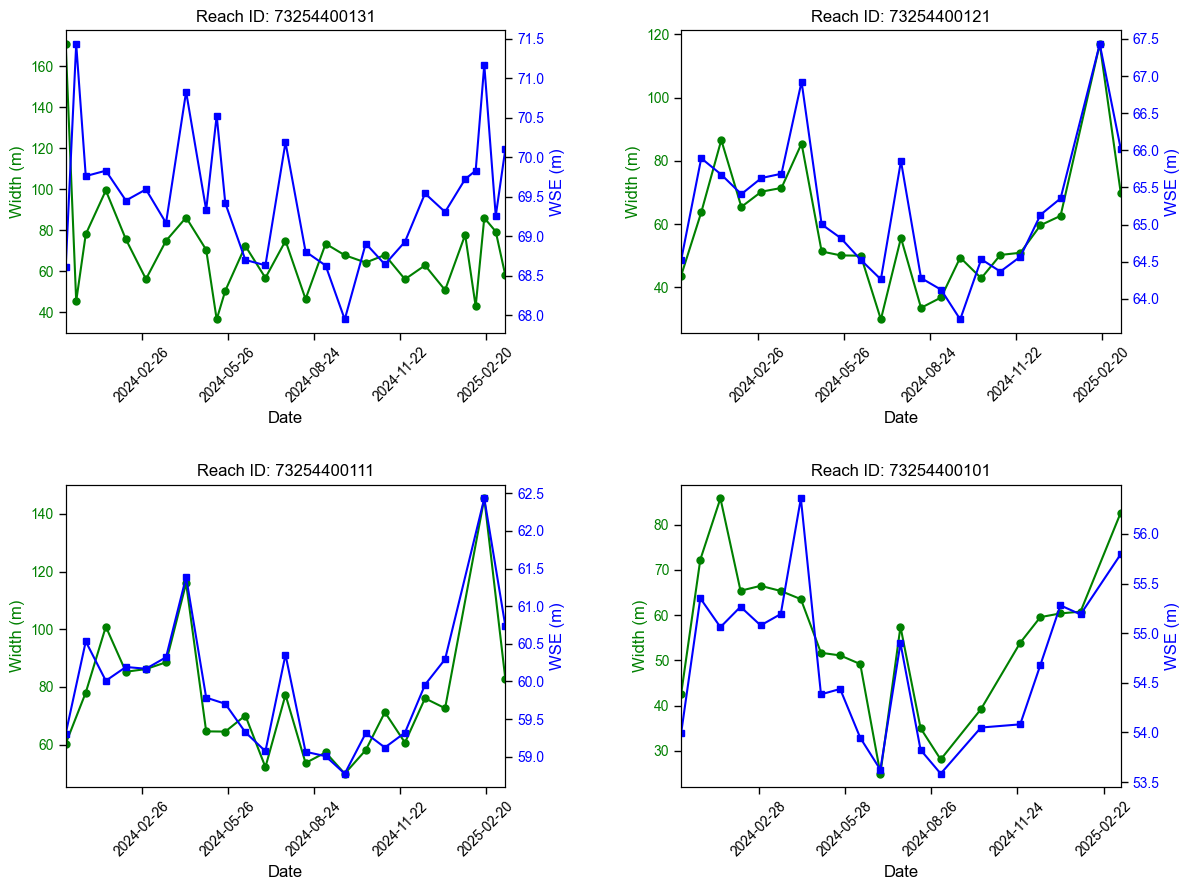

In [9]:
# Plot width & WSE series
def show_all_reaches_time_series(df_reaches):
    number_figs=len(df_reaches)
    nrows=int(sqrt(number_figs))
    ncols=ceil(number_figs/nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 9), squeeze=False)
    
    axes_flat = axes.flatten()
    
    for i, df_reach in enumerate(df_reaches):
        if i < number_figs:
            ax = axes_flat[i]
            
            ax.plot(df_reach.date, df_reach.width, '-', color='green', marker='o', markersize=5)
            ax.set_xlabel('Date', fontdict={'size':12})
            ax.set_ylabel('Width (m)', fontdict={'size':12}, color='green')
            ax.tick_params(axis='y', labelcolor='green', labelsize=10)
            ax.tick_params(which='major', length=5, width=1)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            ax.tick_params(axis='x', labelrotation=45, labelsize=10)
            
            ax2 = ax.twinx()
            ax2.plot(df_reach.date, df_reach.wse, '-', color='blue', marker='s', markersize=5)
            ax2.set_ylabel('WSE (m)', fontdict={'size':12}, color='blue')
            ax2.tick_params(axis='y', labelcolor='blue', labelsize=10)
            ax2.tick_params(which='major', length=5, width=1)
            
            ax.set_xlim([df_reach.date.min(), df_reach.date.max()])
            
            if 'reach_id' in df_reach.columns:
                ax.set_title(f'Reach ID: {df_reach.reach_id.iloc[0]}', fontsize=12)
            else:
                ax.set_title(f'Reach {i+1}', fontsize=12)
    
    for j in range(number_figs, nrows * ncols):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.4)
    plt.show()

show_all_reaches_time_series(df_reaches)

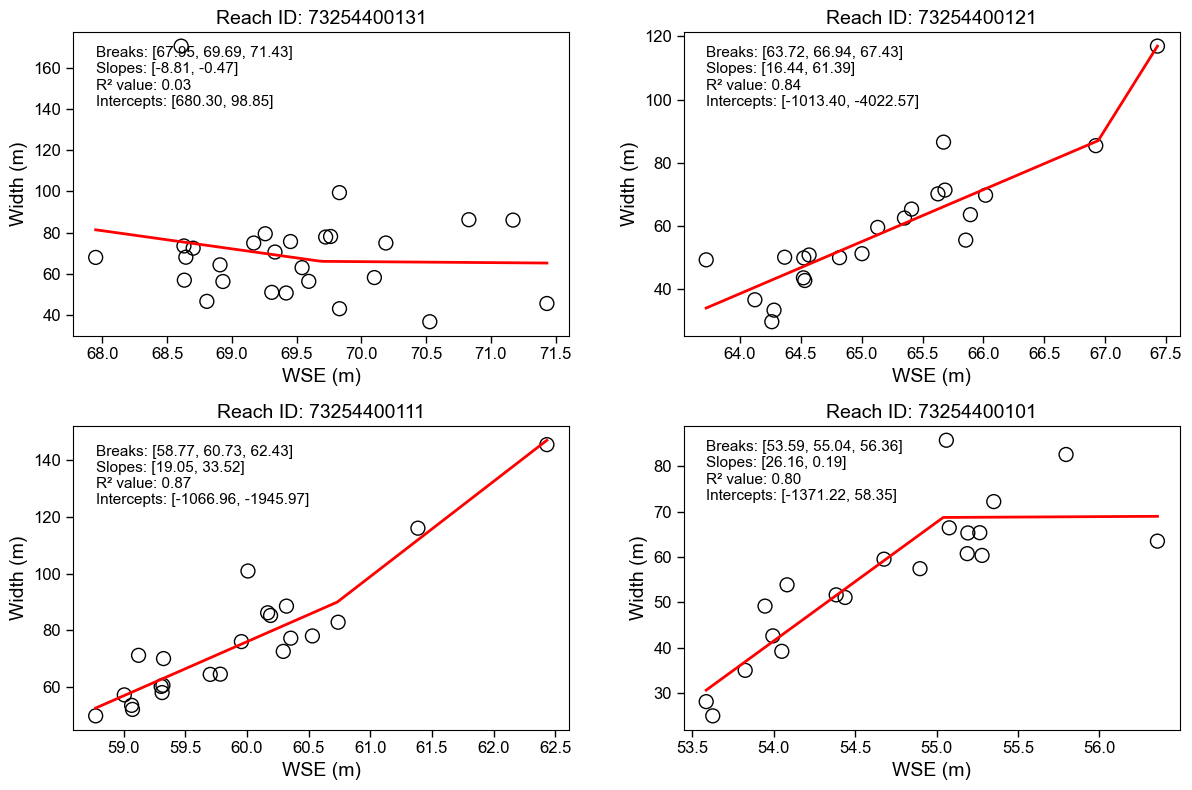

In [10]:
# Width-WSE relationship & piecewise linear fitting

def find_optimal_breaks(x, y, myPWLF, num_segments=2):
    best_r2 = -np.inf
    best_breaks = [x.min(),0.5*(x.min()+x.max()), x.max()] # to prevent error
    x_range = np.linspace(x.min(), x.max(), 100)  # Possible breakpoints
    
    for b1 in x_range[1:-1]:
        breaks = [x.min(), b1, x.max()]
        myPWLF.fit_with_breaks(breaks)
        slopes = myPWLF.calc_slopes()
        
        if all(slope > 0 for slope in slopes):
            r2 = myPWLF.r_squared()
            if r2 > best_r2:
                best_r2 = r2
                best_breaks = breaks
    
    return best_breaks

def show_all_reaches_relationship(df_reaches):
    number_figs=len(df_reaches)
    nrows=int(sqrt(number_figs))
    ncols=ceil(number_figs/nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), squeeze=False)
    
    axes_flat = axes.flatten()
    
    for i, df_reach in enumerate(df_reaches):
        if i < number_figs:
            ax = axes_flat[i]
            
            myPWLF = pwlf.PiecewiseLinFit(df_reach['wse'], df_reach['width'])
            optimal_breaks = find_optimal_breaks(df_reach['wse'], df_reach['width'], myPWLF)
            myPWLF.fit_with_breaks(optimal_breaks)
            
            xHat = np.linspace(df_reach['wse'].min(), df_reach['wse'].max(), 100)
            yHat = myPWLF.predict(xHat)
            ax.scatter(df_reach['wse'], df_reach['width'], s=100, facecolor='none', edgecolor='k', linewidth=1)
            ax.plot(xHat, yHat, 'r-', linewidth=2)
            ax.set_xlabel('WSE (m)', fontdict={'size':14})
            ax.set_ylabel('Width (m)', fontdict={'size':14})
            ax.tick_params(labelsize=12)
            ax.tick_params(which='major', length=5, width=1)
            
            formatted_breaks = [f'{break_value:.2f}' for break_value in optimal_breaks]
            breaks_str = '[' + ', '.join(formatted_breaks) + ']'
            
            slopes = myPWLF.calc_slopes()
            formatted_slopes = [f'{slope:.2f}' for slope in slopes]
            slopes_str = '[' + ', '.join(formatted_slopes) + ']'
            
            intercepts = myPWLF.intercepts
            formatted_intercepts = [f'{intercept:.2f}' for intercept in intercepts]
            intercepts_str = '[' + ', '.join(formatted_intercepts) + ']'
            
            text = f'Breaks: {breaks_str}\nSlopes: {slopes_str}\nR² value: {myPWLF.r_squared():.2f}\nIntercepts: {intercepts_str}'
            ax.text(df_reach['wse'].min(), df_reach['width'].max(), text, fontsize=11,va='top')
            df_reach['fitted_width']=myPWLF.predict(df_reach['wse'])
            
            if 'reach_id' in df_reach.columns:
                ax.set_title(f'Reach ID: {df_reach.reach_id.iloc[0]}', fontsize=14)
            else:
                ax.set_title(f'Reach {i+1}', fontsize=12)

    for j in range(number_figs, nrows * ncols):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.23)
    plt.show()

    return df_reaches
    
df_reaches=show_all_reaches_relationship(df_reaches)


In [11]:
# Save processed observations
import pickle
RunDir=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub
filename=RunDir+ r'\df_reaches_hydrocorn_rechindex0.pkl'
os.makedirs(RunDir, exist_ok=True)
with open(filename, 'wb') as output:
    pickle.dump(df_reaches, output, pickle.HIGHEST_PROTOCOL)


## Step 3: Make Preparation File

In [12]:
# Calculate overlapping dates across all reaches
date_sets = [set(df['date']) for df in df_reaches]
common_dates = set.intersection(*date_sets)
common_dates_sorted = sorted(list(common_dates))
print(f'Overlapping dates: {len(common_dates_sorted)} days')
reaches_common=[]
for i in range(len(df_reaches)):
    df_reach_i_common = df_reaches[i][df_reaches[i]['date'].isin(common_dates_sorted)]
    reaches_common.append(df_reach_i_common)

Overlapping dates: 18 days


In [13]:
# Important! common_dates_sorted[0] is first_day parameter in discharge estimate jupyter
common_dates_sorted[:10]


[Timestamp('2023-12-29 00:00:00'),
 Timestamp('2024-01-19 00:00:00'),
 Timestamp('2024-02-09 00:00:00'),
 Timestamp('2024-03-01 00:00:00'),
 Timestamp('2024-03-22 00:00:00'),
 Timestamp('2024-04-12 00:00:00'),
 Timestamp('2024-05-03 00:00:00'),
 Timestamp('2024-05-23 00:00:00'),
 Timestamp('2024-06-13 00:00:00'),
 Timestamp('2024-07-04 00:00:00')]

In [14]:
# Construct observation matrices
reach_lengthes=neighbor_length.copy()
mid_distances=[]
cumulative_distance=0
for length in reach_lengthes:
    mid_distances.append(cumulative_distance+length/2)
    cumulative_distance+=length

number_overpass=len(reaches_common[0])
date_days=[]
cumulative_day=1
for date in common_dates_sorted:
    cumulative_day=(date-common_dates_sorted[0]).days+1
    date_days.append(cumulative_day)

Heights=np.empty([number_reaches, number_overpass],dtype=float)
Heights_baseflow=np.empty(number_reaches,dtype=float)
Slopes=np.empty([number_reaches, number_overpass],dtype=float)
Widths=np.empty([number_reaches, number_overpass],dtype=float)

for reach_index, reach_common in enumerate(reaches_common):
    Heights[reach_index,:]=reach_common['wse']
    Heights_baseflow[reach_index]=reach_common['wse'].iloc[0]
    Slopes[reach_index,:]=reach_common['slope2']
    if type_sub=='fit':
        Widths[reach_index,:]=reach_common['fitted_width']
    else:
        Widths[reach_index,:]=reach_common['width']

stdslope=np.mean(np.std(Slopes,axis=1))
stdheight=np.mean(np.std(Heights,axis=1))
stdwidth=np.mean(np.std(Widths,axis=1))

In [15]:
# Output observation file
def output_obsfile(file_path):
    output_text = "Number of reaches\n"
    output_text += f"{number_reaches}\n"
    
    output_text += "Reach midpoint distance downstream, m\n"
    mid_distances_str = "\t".join([f"{dist:.6f}" for dist in mid_distances]) + "\t\n"
    output_text += mid_distances_str
    
    output_text += "Reach lengths, m\n"
    reach_lengths_str = "\t".join([f"{length:.6f}" for length in reach_lengthes]) + "\t\n"
    output_text += reach_lengths_str
    
    output_text += "Number of overpasses\n"
    output_text += f"{number_overpass}\n"
    
    output_text += "Time, Days\n"
    time_days_str = "\t".join([f"{day:.6f}" for day in date_days]) + "\t\n"
    output_text += time_days_str
    
    output_text += "Height, meters\n"
    for reach_index in range(number_reaches):
        heights_str = "\t".join([f"{height:.6f}" for height in Heights[reach_index,:]]) + "\t\n"
        output_text += heights_str
    
    output_text += "Height at baseflow, m\n"
    baseflow_heights_str = "\t".join([f"{height:.6f}" for height in Heights_baseflow]) + "\t\n"
    output_text += baseflow_heights_str
    
    output_text += "Slope, m/m\n"
    for reach_index in range(number_reaches):
        slopes_str = "\t".join([f"{slope:.8f}" for slope in Slopes[reach_index,:]]) + "\t\n"
        output_text += slopes_str
    
    output_text += "Width, m\n"
    for reach_index in range(number_reaches):
        widths_str = "\t".join([f"{width:.6f}" for width in Widths[reach_index,:]]) + "\t\n"
        output_text += widths_str
    
    output_text += "Standard deviation on slope m/m\n"
    output_text += f"{stdslope:.8f}\n"
    
    output_text += "Standard deviation on height m\n"
    output_text += f"{stdheight:.6f}\n"
    
    output_text += "Standard deviation on width m\n"
    output_text += f"{stdwidth:.6f}\n"
    
    with open(file_path, "w") as f:
        f.write(output_text)
    
    print(f"Obs written into {file_path}")

file_path=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub+r'\SWOTObs_by_us.txt'
output_obsfile(file_path)

Obs written into d:\Workstation\SWOT\discharge\calibration\sample_reach\PepsiSac_obs_optm\SWOTObs_by_us.txt


In [16]:
# Check parameters from SoS

prior_nc=nc.Dataset(prior_path,format='NETCDF4')
result_nc=nc.Dataset(result_path,format='NETCDF4')

Dis_Algorithm=['hivdi','neobam','momma','metroman','sad','sic4dvar']
Gauge_Agency='USGS'
sos_reachids_rs=result_nc['reaches']['reach_id'][:]
sos_reachids_pr=prior_nc['reaches']['reach_id'][:]
sos_lons_rs=result_nc['reaches']['x'][:]
sos_lats_rs=result_nc['reaches']['y'][:]

sos_A0hats_rs=result_nc['metroman']['A0hat'][:]
sos_nahats_rs=result_nc['metroman']['nahat'][:]
sos_x1hats_rs=result_nc['metroman']['x1hat'][:]

sos_metroqs_rs=result_nc['metroman']['allq'][:]
sos_mommaqs_rs=result_nc['momma']['Q'][:]
sos_times_rs=result_nc['reaches']['time'][:]

sos_momma_B_rs=result_nc['moi']['momma']['B'][:]
sos_momma_H_rs=result_nc['moi']['momma']['H'][:]
sos_momma_n_rs=result_nc['momma']['n'][:]

river_indexes=np.where(sos_reachids_rs==int(target_reachid))[0]

SWOT_gauge_reaches=prior_nc[Gauge_Agency][f'{Gauge_Agency}_reach_id'][:].filled()
gauge_index=np.where(SWOT_gauge_reaches==int(target_reachid))[0]
gauge_time=prior_nc[Gauge_Agency][f'{Gauge_Agency}_qt'][gauge_index].filled().astype(int)[0]
gauge_discharge=prior_nc[Gauge_Agency][f'{Gauge_Agency}_q'][gauge_index].filled()[0]
nonmissing_index= (gauge_discharge>=0) & (gauge_time>1000) & (gauge_discharge<100000)
gauge_discharge=gauge_discharge[nonmissing_index]
gauge_time=gauge_time[nonmissing_index]
gauge_time_datetime=np.array([datetime.datetime.fromordinal(gt) for gt in gauge_time])
prior_WBM_discharge=prior_nc['model']['mean_q'][:].filled()[river_indexes[0]]

print(len(gauge_time_datetime))
print('Prior Q:',prior_WBM_discharge)

11543
Prior Q: 56.29087448120117


In [17]:
# MCMC parameters
Chain_length=10000
Burn_in=2000
Seed=9
start_and_end_day=[1,date_days[-1]]
Prior_meanQ=prior_WBM_discharge
prior_cvq=0.5
nopt=5

In [18]:
# Construct parameter file
txt_content = f"""Chain length
{Chain_length}
Burn in
{Burn_in}
Random Number Seed
{Seed}
Initial and final time (first and last days) to use in estimate
{start_and_end_day[0]}\t{start_and_end_day[1]}
Prior mean on mean discharge [m3/s]
{Prior_meanQ}
Prior coefficient of variation on mean flow [fraction... set to 0.5 for typical application
{prior_cvq}
n version to use
{nopt}
"""
file_path=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub+r'\params_by_us.txt'

with open(file_path, 'w') as file:
    file.write(txt_content)

print(f"Params written into {file_path}")

Params written into d:\Workstation\SWOT\discharge\calibration\sample_reach\PepsiSac_obs_optm\params_by_us.txt


## Step 4: Obtain S3 Data

In [20]:
# Exrtact WSE from S3 json

with open(S3_json_path,'r') as g:
    S3_validate_json=json.load(g)
    
S3_nodeids=np.array([item['nodeid'] for item in S3_validate_json])
target_S3_validate_VS= S3_validate_json[np.where(S3_nodeids==S3_nodeid)[0][0]]
target_VS_time_excel=target_S3_validate_VS['monitor_time']#excel format
target_VS_wse=target_S3_validate_VS['monitor_wse']
print(len(target_VS_wse))

60


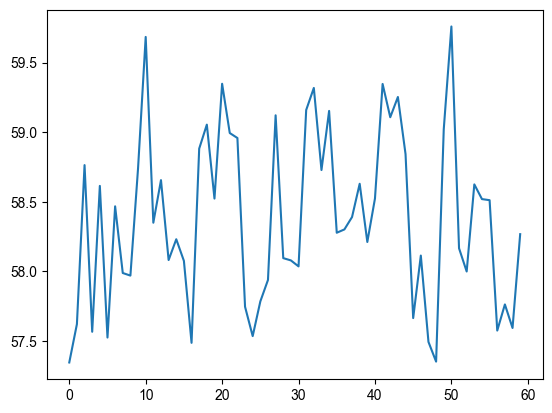

In [21]:
plt.plot(target_VS_wse)

In [22]:
# Calibrate S3 water level to SWOT water level based on their overlapping period
def number2datetime(number_list):
    excel_base=datetime.datetime(1899, 12, 30)
    return [excel_base + datetime.timedelta(days=num) for num in number_list]
swot_wse=np.array(Heights[target_reach_index,:])
swot_time=np.array(common_dates_sorted)
s3_time=np.array(number2datetime(target_VS_time_excel))
s3_wse=np.array(target_VS_wse)
overlap_min=max(swot_time.min(),s3_time.min())
overlap_max=min(swot_time.max(),s3_time.max())
swot_median=np.median(swot_wse[np.where((swot_time>=overlap_min)&(swot_time<=overlap_max))[0]])
s3_median=np.median(s3_wse[np.where((s3_time>=overlap_min)&(s3_time<=overlap_max))[0]])
print('start time: ',overlap_min,' ; end time: ',overlap_max)
print('SWOT median:',swot_median)
print('S3 median:',s3_median)
if median_bias is None:
    median_bias=s3_median-swot_median
print(f'S3 wse - SWOT wse: {median_bias} m')
target_VS_wse_corr=np.array(target_VS_wse)-median_bias

start time:  2023-12-29 00:00:00  ; end time:  2024-10-09 03:09:58.287431
SWOT median: 54.8986
S3 median: 58.2672541706846
S3 wse - SWOT wse: 4 m


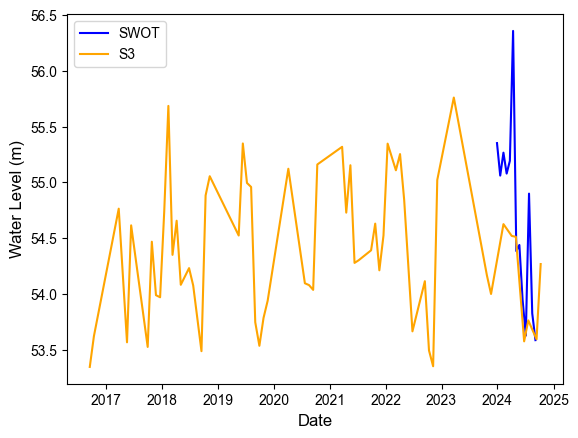

In [23]:
# Plot overlapping period WSE
swot_idx=np.where((swot_time>=overlap_min)&(swot_time<=overlap_max))[0]
s3_idx=np.where((s3_time>=overlap_min)&(s3_time<=overlap_max))[0]
plt.plot(swot_time[swot_idx],swot_wse[swot_idx],label='SWOT',color='blue')
plt.plot(s3_time,target_VS_wse_corr,label='S3',color='orange')
plt.legend()
plt.xlabel('Date',fontdict={'size':12})
plt.ylabel('Water Level (m)',fontdict={'size':12})
plt.show()

In [24]:
#获取S3对应拟合河宽
myPWLF = pwlf.PiecewiseLinFit(df_reaches[target_reach_index]['wse'], df_reaches[target_reach_index]['width'])
optimal_breaks = find_optimal_breaks(df_reaches[target_reach_index]['wse'], df_reaches[target_reach_index]['width'], myPWLF)
myPWLF.fit_with_breaks(optimal_breaks)
#注意，将水位矫正到实测站的reach上，用的实测站的stage-width关系
S3_fitted_width=myPWLF.predict(target_VS_wse_corr)

In [25]:
def output_S3obsfile(file_path, measured_slope, prior_slope):
    output_text = "NodeID\n"
    output_text += f"{S3_nodeid}\n"

    output_text += "No. of measurements\n"
    output_text += f"{len(target_VS_wse_corr)}\n"

    output_text += "Measured slope, m/m\n"
    output_text += f"{measured_slope:.8f}\n"

    output_text += "Prior slope, m/m\n"
    output_text += f"{prior_slope:.8f}\n"

    output_text += "Excel date\n"
    excel_date_str = "\t".join([f"{int(date)}" for date in target_VS_time_excel]) + "\t\n"
    output_text += excel_date_str
    
    output_text += "Original height, m\n"
    original_h_str = "\t".join([f"{height:.6f}" for height in target_VS_wse]) + "\t\n"
    output_text += original_h_str
    
    output_text += "Corrected height, m\n"
    corrected_h_str = "\t".join([f"{height:.6f}" for height in target_VS_wse_corr]) + "\t\n"
    output_text += corrected_h_str

    output_text += "Fitted width, m\n"
    fitted_w_str = "\t".join([f"{width:.6f}" for width in S3_fitted_width]) + "\t\n"
    output_text += fitted_w_str

    # 将输出写入文件
    with open(file_path, "w") as f:
        f.write(output_text)
    
    print(f"Obs written into {file_path}")

measured_slope=np.mean(df_reaches[target_reach_index]['slope2'])

file_path=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub+r'\S3_obs_noHcor.txt'
output_S3obsfile(file_path, measured_slope, prior_slope)

Obs written into d:\Workstation\SWOT\discharge\calibration\sample_reach\PepsiSac_obs_optm\S3_obs_noHcor.txt
